<a href="https://colab.research.google.com/github/ColleyMo/MSc-Dissertation/blob/main/MSc_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading and Inspection
- loading Dataset and visualising **frames**

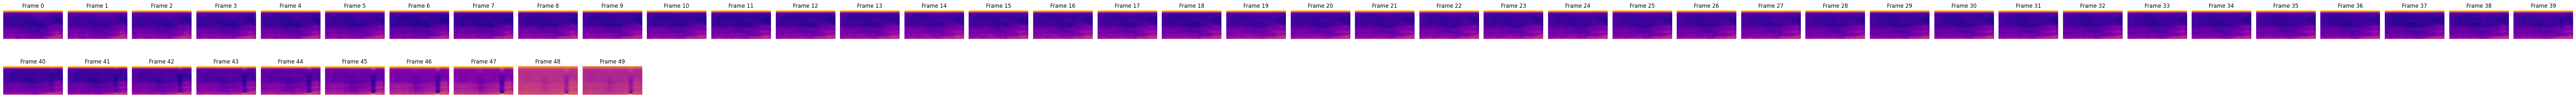

In [ ]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# Load the .mat file
mat_data = scipy.io.loadmat("/content/P1X2_train_norm.mat")

# select data set structure
data = mat_data['P1X2_train_norm']

# Visualize all frames
total_frames = data.shape[2]
num_frames_to_plot = 50

# Determine grid size for subplots
n_cols = 40 # Number of columns in the grid, adjust as needed
n_rows = (num_frames_to_plot + n_cols - 1) // n_cols # Calculate number of rows

# Visualize all frames
plt.figure(figsize=(n_cols * 2, n_rows * 2)) # Adjust figure size for a grid layout
for i in range(50):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(data[:, :, i], cmap='plasma') # Assuming grayscale images
    plt.title(f'Frame {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Preprocessing


*apply*  normalization, resizing, or filtering.


In [ ]:
# Reshape the data to have frames as the first dimension
preprocessed_data = np.transpose(data, (2, 0, 1))

# Normalize pixel values to the range [0, 1]
preprocessed_data = preprocessed_data / preprocessed_data.max()

print("Shape of preprocessed data:", preprocessed_data.shape)
print("Min pixel value:", preprocessed_data.min())
print("Max pixel value:", preprocessed_data.max())

Shape of preprocessed data: (200, 120, 250)
Min pixel value: -0.9996548797184142
Max pixel value: 1.0


Reshape each frame into a 1D vector and stack them into a single 2D array.

In [ ]:
# Reshape each frame into a 1D vector and stack them
features = preprocessed_data.reshape(preprocessed_data.shape[0], -1)
print("Shape of the features array:", features.shape)

Shape of the features array: (200, 30000)


## Model selection, training and Evaluation.

Choose appropriate model and train it using the prepared data.

In [ ]:
from sklearn.cluster import KMeans

# Machine learning task: Clustering

# Instantiate the chosen model (assuming 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Train the model using the features data
kmeans.fit(features)

# The trained model is now stored in the 'kmeans' variable
print("KMeans model training completed.")

KMeans model training completed.


Evaluation

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Calculate the inertia
inertia = kmeans.inertia_

# Calculate the silhouette score
if features.shape[0] > 1 and kmeans.n_clusters > 1:
  silhouette_avg = silhouette_score(features, kmeans.labels_)
else:
  silhouette_avg = "N/A (requires more than 1 sample and >1 cluster)"

# Calculate the Davies-Bouldin Index
# Requires at least 2 clusters and more than 1 sample
if features.shape[0] > 1 and kmeans.n_clusters > 1:
  davies_bouldin_avg = davies_bouldin_score(features, kmeans.labels_)
else:
  davies_bouldin_avg = "N/A (requires more than 1 sample and >1 cluster)"

# Calculate the Calinski-Harabasz Index
# Requires at least 2 clusters and more than 1 sample
if features.shape[0] > 1 and kmeans.n_clusters > 1:
  calinski_harabasz_avg = calinski_harabasz_score(features, kmeans.labels_)
else:
  calinski_harabasz_avg = "N/A (requires more than 1 sample and >1 cluster)"


# Print the inertia and silhouette score
print(f"Inertia: {inertia}")
print(f"Silhouette Score: {silhouette_avg}")
print(f"Davies-Bouldin Index: {davies_bouldin_avg}")
print(f"Calinski-Harabasz Index: {calinski_harabasz_avg}")

Inertia: 5464.923296733629
Silhouette Score: 0.4901825835299471
Davies-Bouldin Index: 0.8897346195295858
Calinski-Harabasz Index: 126.61499023697284


**Pseudo Labelling Phase**

Inertia: 5464.923296733629
Silhouette Score: 0.4901825835299471

Interpretation:
The inertia of 5464.9233 represents the sum of squared distances of samples to their closest cluster center. A lower inertia generally indicates better clustering.
The silhouette score of 0.4902 measures how similar an object is to its own cluster compared to other clusters. A score close to 1 indicates that the data point is far away from the neighboring clusters, a score of 0 means the data point is on or very close to the decision boundary between two neighboring clusters, and negative values indicate that those data points might have been assigned to the wrong cluster. A score of 0.52 suggests reasonably good clustering.

Davies-Bouldin Index: 0.8897346195295858
Calinski-Harabasz Index: 126.61499023697284

Interpretation of Additional Metrics:
The Davies-Bouldin Index of 0.8897 represents the average similarity between clusters. A lower Davies-Bouldin Index indicates better separation between clusters.

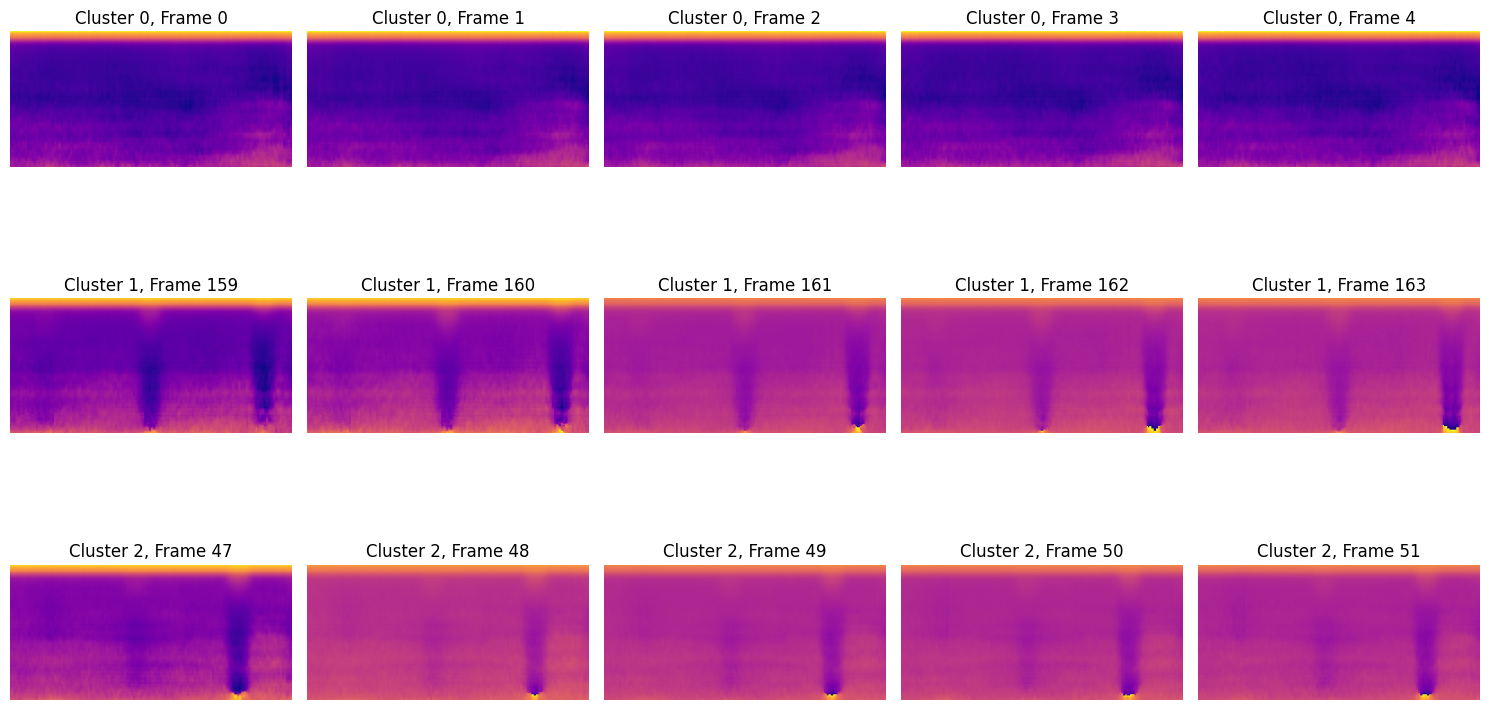

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans # Import KMeans to access the trained model and labels



# Get the cluster labels
cluster_labels = kmeans.labels_

# Calculate the inertia
inertia = kmeans.inertia_

# Calculate the silhouette score
# The silhouette score requires at least 2 clusters and more than 1 sample
if features.shape[0] > 1 and kmeans.n_clusters > 1:
  silhouette_avg = silhouette_score(features, cluster_labels)
else:
  silhouette_avg = "N/A (requires more than 1 sample and >1 cluster)"


# Interpretation of Inertia and Silhouette Score
print(f"Inertia: {inertia}")
print(f"Silhouette Score: {silhouette_avg}")

print("\nInterpretation:")
print(f"The inertia of {inertia:.4f} represents the sum of squared distances of samples to their closest cluster center. A lower inertia generally indicates better clustering.")
if isinstance(silhouette_avg, float):
  print(f"The silhouette score of {silhouette_avg:.4f} measures how similar an object is to its own cluster compared to other clusters. A score close to 1 indicates that the data point is far away from the neighboring clusters, a score of 0 means the data point is on or very close to the decision boundary between two neighboring clusters, and negative values indicate that those data points might have been assigned to the wrong cluster. A score of 0.52 suggests reasonably good clustering.")
else:
  print(f"Silhouette Score: {silhouette_avg}") # Print N/A message


# Calculate Davies-Bouldin Index
# Requires at least 2 clusters and more than 1 sample
if features.shape[0] > 1 and kmeans.n_clusters > 1:
  davies_bouldin_avg = davies_bouldin_score(features, cluster_labels)
else:
  davies_bouldin_avg = "N/A (requires more than 1 sample and >1 cluster)"

print(f"\nDavies-Bouldin Index: {davies_bouldin_avg}")

# Calculate Calinski-Harabasz Index
# Requires at least 2 clusters and more than 1 sample
if features.shape[0] > 1 and kmeans.n_clusters > 1:
    calinski_harabasz_avg = calinski_harabasz_score(features, cluster_labels)
else:
    calinski_harabasz_avg = "N/A (requires more than 1 sample and >1 cluster)"

print(f"Calinski-Harabasz Index: {calinski_harabasz_avg}")


print("\nInterpretation of Additional Metrics:")
if isinstance(davies_bouldin_avg, float):
    print(f"The Davies-Bouldin Index of {davies_bouldin_avg:.4f} represents the average similarity between clusters. A lower Davies-Bouldin Index indicates better separation between clusters.")
else:
    print(f"Davies-Bouldin Index: {davies_bouldin_avg}") # Print N/A message

if isinstance(calinski_harabasz_avg, float):
    print(f"The Calinski-Harabasz Index of {calinski_harabasz_avg:.4f} is the ratio of the sum of between-cluster dispersion and within-cluster dispersion. A higher Calinski-Harabasz Index indicates better defined clusters.")
else:
    print(f"Calinski-Harabasz Index: {calinski_harabasz_avg}") # Print N/A message


# Visualize representative frames from each cluster (already present)
# Find the indices of frames belonging to each cluster
frames_per_cluster = {}
for i, label in enumerate(cluster_labels):
    if label not in frames_per_cluster:
        frames_per_cluster[label] = []
    frames_per_cluster[label].append(i)

# Select a few representative frames from each cluster (e.g., the first 5)
num_representative_frames = 5
plt.figure(figsize=(num_representative_frames * 3, kmeans.n_clusters * 3))

for cluster_label in sorted(frames_per_cluster.keys()):
    representative_indices = frames_per_cluster[cluster_label][:num_representative_frames]
    for i, frame_index in enumerate(representative_indices):
        plt.subplot(kmeans.n_clusters, num_representative_frames, cluster_label * num_representative_frames + i + 1)
        # Use the original data for visualization before preprocessing
        plt.imshow(data[:, :, frame_index], cmap='plasma')
        plt.title(f'Cluster {cluster_label}, Frame {frame_index}')
        plt.axis('off')

plt.tight_layout()
plt.show()

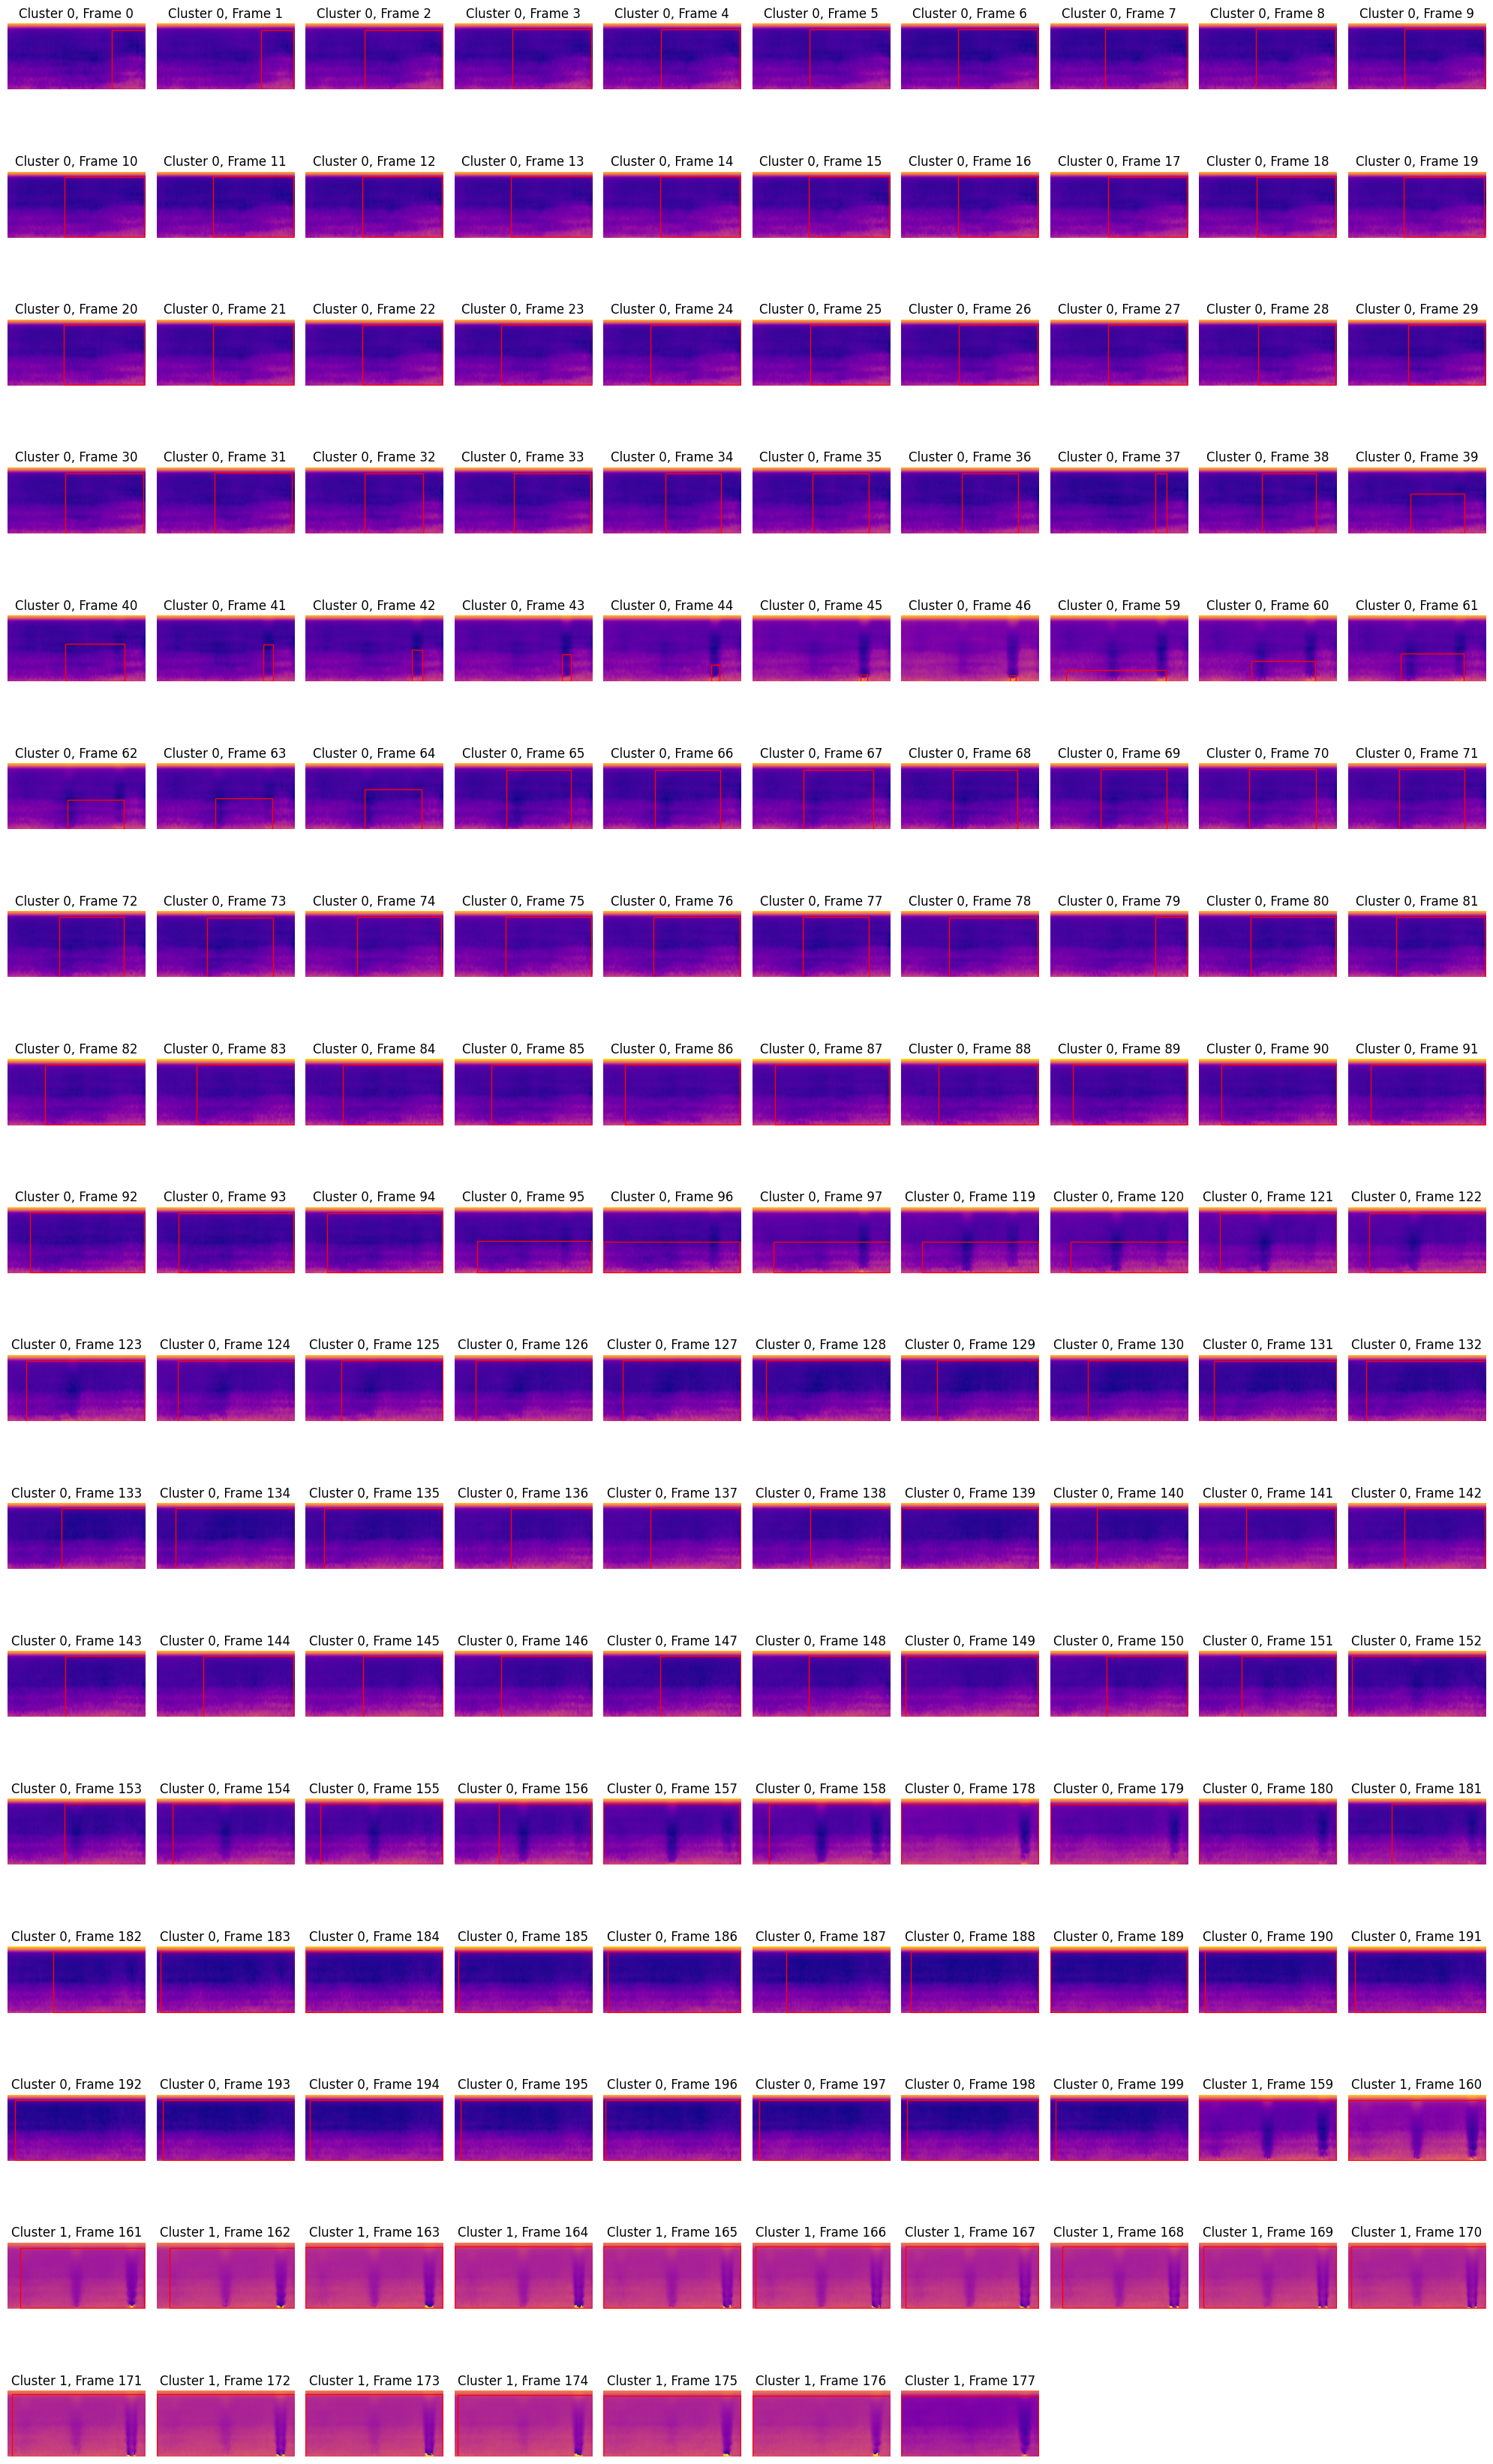

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


# Preprocessing: Reshape and normalize the data
# Reshape the data to have frames as the first dimension
preprocessed_data = np.transpose(data, (2, 0, 1))

# Normalize pixel values to the range [0, 1]
preprocessed_data = preprocessed_data / preprocessed_data.max()

# Feature extraction: Reshape each frame into a 1D vector
features = preprocessed_data.reshape(preprocessed_data.shape[0], -1)

# Train the KMeans model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(features)

# Select a representative frame from Cluster 2 as a reference
# use the first frame assigned to Cluster 2
cluster_labels = kmeans.labels_
cluster_2_indices = [i for i, label in enumerate(cluster_labels) if label == 2]

if not cluster_2_indices:
    print("Cluster 2 is empty. Cannot use it as a reference.")
else:
    reference_frame_index = cluster_2_indices[0]
    reference_frame = data[:, :, reference_frame_index]

    # Iterate through all frames in Cluster 0 and Cluster 1
    clusters_to_compare = [0, 1]
    difference_threshold = 0.1 # Adjust this threshold as needed

    all_frames_to_plot = []
    for cluster_label in clusters_to_compare:
        cluster_indices = [i for i, label in enumerate(cluster_labels) if label == cluster_label]
        all_frames_to_plot.extend([(frame_index, cluster_label) for frame_index in cluster_indices])

    total_frames_to_plot = len(all_frames_to_plot)
    n_cols = 10  # Adjust as needed
    n_rows = (total_frames_to_plot + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 2, n_rows * 2))
    plot_index = 1

    for frame_index, cluster_label in all_frames_to_plot:
        current_frame = data[:, :, frame_index]

        # Calculate the absolute difference between the current frame and the reference frame
        difference = np.abs(current_frame - reference_frame)

        # Identify areas where the difference is above the threshold
        anomalous_mask = difference > difference_threshold

        # Find the bounding box coordinates for anomalous areas
        rows, cols = np.where(anomalous_mask)

        plt.subplot(n_rows, n_cols, plot_index)
        plt.imshow(current_frame, cmap='plasma')
        plt.title(f'Cluster {cluster_label}, Frame {frame_index}')
        plt.axis('off')

        if rows.size > 0:
            min_row, max_row = np.min(rows), np.max(rows)
            min_col, max_col = np.min(cols), np.max(cols)

            # Draw a bounding box
            rect = plt.Rectangle((min_col, min_row), max_col - min_col, max_row - min_row,
                                 linewidth=1, edgecolor='red', facecolor='none')
            plt.gca().add_patch(rect)

        plot_index += 1

    plt.tight_layout()
    plt.show()

## Prepare data for yolo

Convert the video frames and their corresponding cluster pseudo-labels into a format suitable for training a YOLO model

In [ ]:
import os
import shutil
import numpy as np
from PIL import Image
import scipy.io
import cv2 # Import OpenCV for contour finding

# Import KMeans here
from sklearn.cluster import KMeans

# Define base directory for YOLO dataset
yolo_data_dir = "yolo_dataset_localized" # Using a new directory name

# Create directories for images and labels
image_dir_train = os.path.join(yolo_data_dir, "images", "train")
label_dir_train = os.path.join(yolo_data_dir, "labels", "train")

# Remove existing directories if they exist
if os.path.exists(yolo_data_dir):
    shutil.rmtree(yolo_data_dir)

os.makedirs(image_dir_train)
os.makedirs(label_dir_train)

# --- Incorporate Data Loading, Preprocessing, and Clustering ---

# Load the .mat file
data_filename = "/content/P1X2_train_norm.mat" # Assuming this is the training data
mat_data = scipy.io.loadmat(data_filename)

# Print the keys and types in the loaded .mat file for inspection
print(f"Keys available in {data_filename}: {mat_data.keys()}")
for key, value in mat_data.items():
    print(f"  Key: {key}, Type: {type(value)}, Shape: {getattr(value, 'shape', 'N/A')}")


# Modified: Explicitly check for the known correct key and verify its type and dimensions
data_key = 'P1X2_train_norm'
data = None

if data_key in mat_data:
    value = mat_data[data_key]
    if isinstance(value, np.ndarray) and value.ndim >= 3:
        data = value
        print(f"Successfully identified and loaded data from key: {data_key}")
    else:
        print(f"Error: Item under key '{data_key}' is not a numpy array with sufficient dimensions.")
        print(f"  Type: {type(value)}, Shape: {getattr(value, 'shape', 'N/A')}")
else:
    print(f"Error: Expected data key '{data_key}' not found in {data_filename}. Available keys: {mat_data.keys()}")


if data is None:
    raise ValueError(f"Could not find a suitable data array in {data_filename}")


# Preprocessing: Reshape the data to have frames as the first dimension
preprocessed_data = np.transpose(data, (2, 0, 1))

# Normalize pixel values to the range [0, 1]
global_max = preprocessed_data.max()
if global_max > 0:
    preprocessed_data = preprocessed_data / global_max
else:
    print("Max pixel value is 0 or less, skipping normalization by division.")


# Feature extraction: Reshape each frame into a 1D vector
features = preprocessed_data.reshape(preprocessed_data.shape[0], -1)

# Clustering: Train KMeans model (assuming 3 clusters)
# Instantiate the chosen model (assuming 3 clusters, as used previously)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for KMeans
# Train the model using the features data
kmeans.fit(features)
# Get the cluster labels
cluster_labels = kmeans.labels_

# --- Generate YOLO Annotations based on Difference Thresholding ---

# Identify the defective cluster based on visualization (assuming cluster 2 is defective)
defective_cluster_label = 2  # <--- Modify this based on your visualization

# Select a reference frame from the defective cluster
cluster_2_indices = [i for i, label in enumerate(cluster_labels) if label == defective_cluster_label]

if not cluster_2_indices:
    print(f"Cluster {defective_cluster_label} is empty. Cannot use it as a reference for difference calculation.")
    reference_frame = None # Handle the case where the defective cluster is empty
else:
    reference_frame_index = cluster_2_indices[0]
    # Use the original data for the reference frame calculation
    reference_frame = data[:, :, reference_frame_index]


difference_threshold = 0.15 # Adjust this threshold as needed

# Use all indices for training
train_indices = np.arange(preprocessed_data.shape[0])

# Process training data
for i in train_indices:
    frame = preprocessed_data[i] # Use preprocessed data for saving image
    current_frame_original = data[:, :, i] # Use original data for difference calculation
    label = cluster_labels[i]

    # Save frame as image
    # Convert to uint8 after scaling if necessary, ensure data is in [0, 1] before multiplying by 255
    img = Image.fromarray((frame * 255).astype(np.uint8), mode='L') # Assuming grayscale
    img_path = os.path.join(image_dir_train, f"frame_{i:04d}.png")
    img.save(img_path)

    annotation_path = os.path.join(label_dir_train, f"frame_{i:04d}.txt")

    # Only create annotations for frames that belong to the defective cluster and if a reference frame exists
    if label == defective_cluster_label and reference_frame is not None:
        # Calculate the absolute difference between the current frame and the reference frame
        difference = np.abs(current_frame_original - reference_frame)

        # Create a binary mask where difference is above the threshold
        anomalous_mask = (difference > difference_threshold).astype(np.uint8) * 255 # Convert to uint8 0 or 255

        # Find contours in the anomalous mask
        contours, _ = cv2.findContours(anomalous_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        with open(annotation_path, "w") as f:
            # Iterate through detected contours and create YOLO annotations
            for contour in contours:
                # Get the bounding box for each contour
                x, y, w, h = cv2.boundingRect(contour)

                # Convert bounding box coordinates to YOLO format (normalized)
                # Ensure image dimensions are correctly used for normalization
                img_width = data.shape[1] # Width is the second dimension
                img_height = data.shape[0] # Height is the first dimension

                center_x = (x + w / 2) / img_width
                center_y = (y + h / 2) / img_height
                norm_width = w / img_width
                norm_height = h / img_height

                # Write the annotation to the file (class_id is 0 for anomaly)
                f.write(f"0 {center_x:.6f} {center_y:.6f} {norm_width:.6f} {norm_height:.6f}\n")
    else:
        # Create an empty annotation file for frames not in the defective cluster
        # This is important for YOLO training to know there are no objects in these images
        with open(annotation_path, "w") as f:
            pass # Empty file


print(f"YOLO dataset created with localized bounding box annotations based on difference thresholding in '{yolo_data_dir}'")

Keys available in /content/P1X2_train_norm.mat: dict_keys(['__header__', '__version__', '__globals__', 'P1X2_train_norm'])
  Key: __header__, Type: <class 'bytes'>, Shape: N/A
  Key: __version__, Type: <class 'str'>, Shape: N/A
  Key: __globals__, Type: <class 'list'>, Shape: N/A
  Key: P1X2_train_norm, Type: <class 'numpy.ndarray'>, Shape: (120, 250, 200)
Successfully identified and loaded data from key: P1X2_train_norm


/tmp/ipython-input-2444097070.py:109: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((frame * 255).astype(np.uint8), mode='L') # Assuming grayscale


YOLO dataset created with localized bounding box annotations based on difference thresholding in 'yolo_dataset_localized'


## Choosing and configure yolo model
Select the YOLO model architecture and configure it for training, considering the number of classes.

In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.9 MB/s eta 0:00:00


In [ ]:
import yaml
import numpy as np

# Determine the number of classes based on the unique cluster labels
num_classes = len(np.unique(cluster_labels))

# Create a list of class names
class_names = [f'cluster_{i}' for i in range(num_classes)]

# Define the content of the YAML configuration file
yolo_config = {
    'train': '../train',  # Path relative to the data.yaml file
    'val': '../val',      # Path relative to the data.yaml file
    'nc': num_classes,
    'names': class_names
}

# Define the path to save the YAML file
yolo_data_dir = "yolo_dataset"
config_path = os.path.join(yolo_data_dir, "data.yaml")

# Save the YAML configuration to a file
with open(config_path, 'w') as f:
    yaml.dump(yolo_config, f)

# Print the content of the created data.yaml file
print(f"Content of {config_path}:")
with open(config_path, 'r') as f:
    print(f.read())

Content of yolo_dataset/data.yaml:
names:
- cluster_0
- cluster_1
- cluster_2
nc: 3
train: ../train
val: ../val



### YOLO Model Training

In [ ]:
import yaml
import os
import numpy as np
from ultralytics import YOLO

# Define the base directory for YOLO dataset
yolo_data_dir = "yolo_dataset"

# Define the content of the YAML configuration file with correct relative paths
# We now have only one class: 'defective'
yolo_config = {
    'train': os.path.abspath(os.path.join(yolo_data_dir, 'images', 'train')),  # Use absolute path
    'val': os.path.abspath(os.path.join(yolo_data_dir, 'images', 'train')),      # Set val to images/train to use training data for validation
    'nc': 1, # Set number of classes to 1
    'names': ['defective'] # Set class names to 'defective'
}

# Define the path to save the YAML file
config_path = os.path.join(yolo_data_dir, "data.yaml")

# Save the updated YAML configuration to a file
with open(config_path, 'w') as f:
    yaml.dump(yolo_config, f)

# Print the content of the updated data.yaml file
print(f"Content of updated {config_path}:")
with open(config_path, 'r') as f:
    print(f.read())

# Instantiate a YOLO model
# Using 'yolov8n.pt' for transfer learning
model = YOLO('yolov8n.pt')

# Train the model
# data: path to the updated data.yaml file
# epochs: number of training epochs
# imgsz: image size (matching preprocessed frame dimensions)
# Set the number of classes in the model to 1
model.train(data=config_path, epochs=10, imgsz=120) # Removed nc=1

print("YOLO model training initiated with defective data for training and validation.")

Content of updated yolo_dataset/data.yaml:
names:
- defective
nc: 1
train: /content/yolo_dataset/images/train
val: /content/yolo_dataset/images/train

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=120, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=

train: Scanning /content/yolo_dataset/labels/train.cache... 200 images, 167 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 414.2±172.9 MB/s, size: 9.9 KB)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning /content/yolo_dataset/labels/train.cache... 200 images, 167 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

Plotting labels to runs/detect/train5/labels.jpg... 


...

      10/10         0G     0.4657       1.85     0.8222          2        128: 100%|██████████| 13/13 [00:08<00:00,  1.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.10it/s]

                   all        200         33      0.962      0.879      0.968      0.966



10 epochs completed in 0.031 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 6.2MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]


                   all        200         33      0.961      0.879      0.968      0.966
Speed: 0.1ms preprocess, 8.6ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train5
YOLO model training initiated with defective data for training and validation.


In [ ]:
import yaml
import os
from ultralytics import YOLO

# Define the base directory for the localized YOLO dataset
yolo_data_dir_localized = "yolo_dataset_localized"

# Define the content of the YAML configuration file for the localized dataset
# We still have only one class: 'defective' (class_id 0)
yolo_config_localized = {
    'train': os.path.abspath(os.path.join(yolo_data_dir_localized, 'images', 'train')),  # Use absolute path
    'val': os.path.abspath(os.path.join(yolo_data_dir_localized, 'images', 'train')),      # Set val to images/train to use training data for validation
    'nc': 1, # Set number of classes to 1 for localized anomalies
    'names': ['defective'] # Set class names to 'defective'
}

# Define the path to save the new YAML file
config_path_localized = os.path.join(yolo_data_dir_localized, "data_localized.yaml")

# Save the YAML configuration to a file
with open(config_path_localized, 'w') as f:
    yaml.dump(yolo_config_localized, f)

# Print the content of the created data_localized.yaml file
print(f"Content of {config_path_localized}:")
with open(config_path_localized, 'r') as f:
    print(f.read())

# Instantiate a YOLO model
# Using 'yolov8n.pt' for transfer learning, as done before
model_localized = YOLO('yolov8n.pt')

# Train the model on the localized dataset
# data: path to the new data_localized.yaml file
# epochs: number of training epochs (you can adjust this)
# imgsz: image size (matching preprocessed frame dimensions)
# name: a name for this training run to differentiate the results
model_localized.train(data=config_path_localized, epochs=100, imgsz=120, name="yolo_localized_training")

print(f"YOLO model training initiated on the localized dataset '{yolo_data_dir_localized}'")

Content of yolo_dataset_localized/data_localized.yaml:
names:
- defective
nc: 1
train: /content/yolo_dataset_localized/images/train
val: /content/yolo_dataset_localized/images/train

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset_localized/data_localized.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=120, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.

train: Scanning /content/yolo_dataset_localized/labels/train.cache... 200 images, 168 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 441.6±150.4 MB/s, size: 9.9 KB)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning /content/yolo_dataset_localized/labels/train.cache... 200 images, 168 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

Plotting labels to runs/detect/yolo_localized_training2/labels.jpg... 


...

    100/100         0G      1.384     0.8927     0.7705          0        128: 100%|██████████| 13/13 [00:08<00:00,  1.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.10it/s]

                   all        200        185      0.817      0.217      0.249      0.133



100 epochs completed in 0.298 hours.
Optimizer stripped from runs/detect/yolo_localized_training2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolo_localized_training2/weights/best.pt, 6.2MB

Validating runs/detect/yolo_localized_training2/weights/best.pt...
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]


                   all        200        185      0.865      0.211      0.245       0.14
Speed: 0.1ms preprocess, 8.2ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/yolo_localized_training2
YOLO model training initiated on the localized dataset 'yolo_dataset_localized'


### Testing Model


image 1/1 /content/yolo_dataset_localized_binary/images/train/frame_0000.png: 64x128 (no detections), 25.8ms
Speed: 0.8ms preprocess, 25.8ms inference, 0.9ms postprocess per image at shape (1, 3, 64, 128)


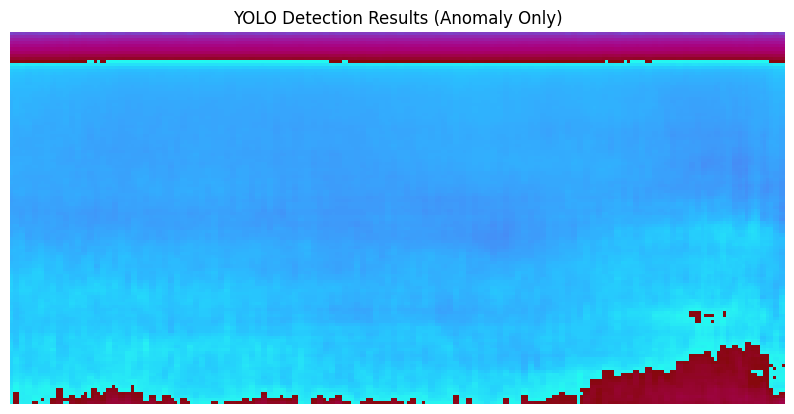

In [11]:
import os
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Define the path to the trained model weights (assuming the best model from the full dataset training)
# You might need to adjust the path based on your training run name
model_path = "runs/detect/yolo_full_dataset_training/weights/best.pt"

# Check if the model path exists
if not os.path.exists(model_path):
    print(f"Error: Model not found at {model_path}. Please verify the path.")
else:
    # Load the trained YOLO model
    model = YOLO(model_path)

    # Define the path to a sample image for inference
    # You can change this to any image in your dataset
    sample_image_path = "yolo_dataset_localized_binary/images/train/frame_0000.png" # Example image

    # Check if the sample image exists
    if not os.path.exists(sample_image_path):
        print(f"Error: Sample image not found at {sample_image_path}. Please verify the path.")
    else:
        # Perform inference on the sample image
        results = model(sample_image_path)

        # Process results and visualize
        for r in results:
            im_array = r.orig_img  # numpy array
            im = im_array.copy()
            # Iterate through detections
            for box in r.boxes.data:
                # Get class ID and confidence score
                class_id = int(box[5])
                confidence = float(box[4])
                x1, y1, x2, y2 = [int(i) for i in box[:4]] # Bounding box coordinates

                # Only draw bounding box and label for the 'anomaly' class (class_id = 1)
                if model.names[class_id] == 'anomaly': # Check class name instead of ID
                    # Draw bounding box (Red color, BGR format)
                    color = (0, 0, 255)  # Red color for anomaly
                    thickness = 2
                    cv2.rectangle(im, (x1, y1), (x2, y2), color, thickness)

                    # Put label (class name and confidence)
                    label = f"{model.names[class_id]}: {confidence:.2f}"
                    font = cv2.FONT_HERSHEY_SIMPLEX
                    font_scale = 0.5
                    font_thickness = 1
                    text_size, _ = cv2.getTextSize(label, font, font_scale, font_thickness)
                    text_origin = (x1, y1 - 10) # Position the text above the box

                    cv2.putText(im, label, text_origin, font, font_scale, color, font_thickness, cv2.LINE_AA)


            # Display the image with detections using matplotlib
            plt.figure(figsize=(10, 10))
            # OpenCV images are BGR, matplotlib expects RGB, so convert
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            plt.title("YOLO Detection Results (Anomaly Only)")
            plt.axis('off')
            plt.show()

## Label generation





In [1]:
import os
import shutil
import numpy as np
from PIL import Image
import scipy.io
import cv2 # Import OpenCV for contour finding
from sklearn.cluster import KMeans # Import KMeans here

# Define base directory for YOLO dataset
yolo_data_dir = "yolo_dataset_localized_binary" # Using a new directory name for binary classification

# Create directories for images and labels
image_dir_train = os.path.join(yolo_data_dir, "images", "train")
label_dir_train = os.path.join(yolo_data_dir, "labels", "train")

# Remove existing directories if they exist
if os.path.exists(yolo_data_dir):
    shutil.rmtree(yolo_data_dir)

os.makedirs(image_dir_train)
os.makedirs(label_dir_train)

# --- Incorporate Data Loading, Preprocessing, and Clustering ---

# Load the .mat file
data_filename = "/content/P1X2_train_norm.mat" # Assuming this is the training data
mat_data = scipy.io.loadmat(data_filename)

# Explicitly check for the known correct key and verify its type and dimensions
data_key = 'P1X2_train_norm'
data = None

if data_key in mat_data:
    value = mat_data[data_key]
    if isinstance(value, np.ndarray) and value.ndim >= 3:
        data = value
        print(f"Successfully identified and loaded data from key: {data_key}")
    else:
        print(f"Error: Item under key '{data_key}' is not a numpy array with sufficient dimensions.")
        print(f"  Type: {type(value)}, Shape: {getattr(value, 'shape', 'N/A')}")
else:
    print(f"Error: Expected data key '{data_key}' not found in {data_filename}. Available keys: {mat_data.keys()}")


if data is None:
    raise ValueError(f"Could not find a suitable data array in {data_filename}")


# Preprocessing: Reshape the data to have frames as the first dimension
preprocessed_data = np.transpose(data, (2, 0, 1))

# Normalize pixel values to the range [0, 1]
global_max = preprocessed_data.max()
if global_max > 0:
    preprocessed_data = preprocessed_data / global_max
else:
    print("Max pixel value is 0 or less, skipping normalization by division.")


# Feature extraction: Reshape each frame into a 1D vector
features = preprocessed_data.reshape(preprocessed_data.shape[0], -1)

# Clustering: Train KMeans model (assuming 3 clusters)
# Instantiate the chosen model (assuming 3 clusters, as used previously)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for KMeans
# Train the model using the features data
kmeans.fit(features)
# Get the cluster labels
cluster_labels = kmeans.labels_

# --- Assign Binary Pseudo-labels based on Cluster Size ---

# 1. Determine the size of each cluster
cluster_sizes = np.bincount(cluster_labels)
print(f"Cluster sizes: {cluster_sizes}")

# 2. Identify the largest cluster (normal)
largest_cluster_label = np.argmax(cluster_sizes)
print(f"Largest cluster (Normal): Cluster {largest_cluster_label}")

# 3. Assign binary pseudo-labels
# 0 for the largest cluster (normal), 1 for all other clusters (anomaly)
binary_pseudo_labels = np.where(cluster_labels == largest_cluster_label, 0, 1)

# Identify the anomaly cluster label(s) for difference calculation
anomaly_cluster_labels = [label for label in np.unique(cluster_labels) if label != largest_cluster_label]
print(f"Anomaly cluster(s): {anomaly_cluster_labels}")


# --- Generate YOLO Annotations based on Difference Thresholding for Anomaly Clusters ---

# Select a reference frame from one of the anomaly clusters for difference calculation
# Choose the first anomaly cluster label if multiple exist
reference_cluster_for_diff = anomaly_cluster_labels[0] if anomaly_cluster_labels else None

reference_frame = None
if reference_cluster_for_diff is not None:
    reference_cluster_indices = [i for i, label in enumerate(cluster_labels) if label == reference_cluster_for_diff]
    if reference_cluster_indices:
        reference_frame_index = reference_cluster_indices[0]
        # Use the original data for the reference frame calculation
        reference_frame = data[:, :, reference_frame_index]
        print(f"Using frame {reference_frame_index} from Cluster {reference_cluster_for_diff} as reference for difference calculation.")
    else:
        print(f"Anomaly Cluster {reference_cluster_for_diff} is empty. Cannot use it as a reference.")
else:
    print("No anomaly clusters found. Cannot perform difference calculation.")


difference_threshold = 0.15 # Adjust this threshold as needed

# Use all indices for training
train_indices = np.arange(preprocessed_data.shape[0])

# Process training data
for i in train_indices:
    frame = preprocessed_data[i] # Use preprocessed data for saving image
    current_frame_original = data[:, :, i] # Use original data for difference calculation
    binary_label = binary_pseudo_labels[i]

    # Save frame as image
    # Convert to uint8 after scaling if necessary, ensure data is in [0, 1] before multiplying by 255
    img = Image.fromarray((frame * 255).astype(np.uint8), mode='L') # Assuming grayscale
    img_path = os.path.join(image_dir_train, f"frame_{i:04d}.png")
    img.save(img_path)

    annotation_path = os.path.join(label_dir_train, f"frame_{i:04d}.txt")

    # Only create annotations with bounding boxes for frames labeled as 'anomaly' (binary_label == 1)
    if binary_label == 1 and reference_frame is not None:
        # Calculate the absolute difference between the current frame and the reference frame
        difference = np.abs(current_frame_original - reference_frame)

        # Create a binary mask where difference is above the threshold
        anomalous_mask = (difference > difference_threshold).astype(np.uint8) * 255 # Convert to uint8 0 or 255

        # Find contours in the anomalous mask
        contours, _ = cv2.findContours(anomalous_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        with open(annotation_path, "w") as f:
            # Iterate through detected contours and create YOLO annotations
            for contour in contours:
                # Get the bounding box for each contour
                x, y, w, h = cv2.boundingRect(contour)

                # Convert bounding box coordinates to YOLO format (normalized)
                # Ensure image dimensions are correctly used for normalization
                img_width = data.shape[1] # Width is the second dimension
                img_height = data.shape[0] # Height is the first dimension

                center_x = (x + w / 2) / img_width
                center_y = (y + h / 2) / img_height
                norm_width = w / img_width
                norm_height = h / img_height

                # Write the annotation to the file with class_id 1 for anomaly
                f.write(f"1 {center_x:.6f} {center_y:.6f} {norm_width:.6f} {norm_height:.6f}\n")
    else:
        # Create an empty annotation file for frames labeled as 'normal' (binary_label == 0)
        # This is important for YOLO training to know there are no objects in these images
        with open(annotation_path, "w") as f:
            pass # Empty file


print(f"YOLO dataset created with binary pseudo-labels and localized bounding box annotations in '{yolo_data_dir}'")

Successfully identified and loaded data from key: P1X2_train_norm
Cluster sizes: [148  19  33]
Largest cluster (Normal): Cluster 0
Anomaly cluster(s): [np.int32(1), np.int32(2)]
Using frame 159 from Cluster 1 as reference for difference calculation.


/tmp/ipython-input-3197096579.py:123: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray((frame * 255).astype(np.uint8), mode='L') # Assuming grayscale


YOLO dataset created with binary pseudo-labels and localized bounding box annotations in 'yolo_dataset_localized_binary'


## Data preprocessing


Ensure that both training and test frames are normalized to the range 0-255 and converted to a consistent color format .



Modify the image saving part of the code to normalize frames to 0-255 and apply the plasma colormap using OpenCV before saving them as images for YOLO training.



In [2]:
import os
import shutil
import numpy as np
from PIL import Image
import scipy.io
import cv2 # Import OpenCV for contour finding
from sklearn.cluster import KMeans # Import KMeans here

# Define base directory for YOLO dataset
yolo_data_dir = "yolo_dataset_localized_binary" # Using a new directory name for binary classification

# Create directories for images and labels
image_dir_train = os.path.join(yolo_data_dir, "images", "train")
label_dir_train = os.path.join(yolo_data_dir, "labels", "train")

# Remove existing directories if they exist
if os.path.exists(yolo_data_dir):
    shutil.rmtree(yolo_data_dir)

os.makedirs(image_dir_train)
os.makedirs(label_dir_train)

# --- Incorporate Data Loading, Preprocessing, and Clustering

# Load the .mat file
data_filename = "/content/P1X2_train_norm.mat" # Assuming this is the training data
mat_data = scipy.io.loadmat(data_filename)

# Explicitly check for the known correct key and verify its type and dimensions
data_key = 'P1X2_train_norm'
data = None

if data_key in mat_data:
    value = mat_data[data_key]
    if isinstance(value, np.ndarray) and value.ndim >= 3:
        data = value
        print(f"Successfully identified and loaded data from key: {data_key}")
    else:
        print(f"Error: Item under key '{data_key}' is not a numpy array with sufficient dimensions.")
        print(f"  Type: {type(value)}, Shape: {getattr(value, 'shape', 'N/A')}")
else:
    print(f"Error: Expected data key '{data_key}' not found in {data_filename}. Available keys: {mat_data.keys()}")


if data is None:
    raise ValueError(f"Could not find a suitable data array in {data_filename}")


# Preprocessing: Reshape the data to have frames as the first dimension
preprocessed_data = np.transpose(data, (2, 0, 1))

# Normalize pixel values to the range [0, 1]
global_max = preprocessed_data.max()
if global_max > 0:
    preprocessed_data = preprocessed_data / global_max
else:
    print("Max pixel value is 0 or less, skipping normalization by division.")


# Feature extraction: Reshape each frame into a 1D vector
features = preprocessed_data.reshape(preprocessed_data.shape[0], -1)

# Clustering: Train KMeans model (assuming 3 clusters)
# Instantiate the chosen model (assuming 3 clusters, as used previously)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for KMeans
# Train the model using the features data
kmeans.fit(features)
# Get the cluster labels
cluster_labels = kmeans.labels_

# --- Assign Binary Pseudo-labels based on Cluster Size ---

# 1. Determine the size of each cluster
cluster_sizes = np.bincount(cluster_labels)
print(f"Cluster sizes: {cluster_sizes}")

# 2. Identify the largest cluster (normal)
largest_cluster_label = np.argmax(cluster_sizes)
print(f"Largest cluster (Normal): Cluster {largest_cluster_label}")

# 3. Assign binary pseudo-labels
# 0 for the largest cluster (normal), 1 for all other clusters (anomaly)
binary_pseudo_labels = np.where(cluster_labels == largest_cluster_label, 0, 1)

# Identify the anomaly cluster label(s) for difference calculation
anomaly_cluster_labels = [label for label in np.unique(cluster_labels) if label != largest_cluster_label]
print(f"Anomaly cluster(s): {anomaly_cluster_labels}")


# --- Generate YOLO Annotations based on Difference Thresholding for Anomaly Clusters ---

# Select a reference frame from one of the anomaly clusters for difference calculation
# Choose the first anomaly cluster label if multiple exist
reference_cluster_for_diff = anomaly_cluster_labels[0] if anomaly_cluster_labels else None

reference_frame = None
if reference_cluster_for_diff is not None:
    reference_cluster_indices = [i for i, label in enumerate(cluster_labels) if label == reference_cluster_for_diff]
    if reference_cluster_indices:
        reference_frame_index = reference_cluster_indices[0]
        # Use the original data for the reference frame calculation
        reference_frame = data[:, :, reference_frame_index]
        print(f"Using frame {reference_frame_index} from Cluster {reference_cluster_for_diff} as reference for difference calculation.")
    else:
        print(f"Anomaly Cluster {reference_cluster_for_diff} is empty. Cannot use it as a reference.")
else:
    print("No anomaly clusters found. Cannot perform difference calculation.")


difference_threshold = 0.15 # Adjust this threshold as needed

# Use all indices for training
train_indices = np.arange(preprocessed_data.shape[0])

# Process training data
for i in train_indices:
    frame = preprocessed_data[i] # Use preprocessed data for saving image
    current_frame_original = data[:, :, i] # Use original data for difference calculation
    binary_label = binary_pseudo_labels[i]

    # Image Formatting and Saving
    # Scale normalized data [0, 1] to [0, 255] and convert to uint8
    frame_uint8 = (frame * 255).astype(np.uint8)

    # Apply colormap using OpenCV
    colormapped_frame = cv2.applyColorMap(frame_uint8, cv2.COLORMAP_PLASMA)

    # Convert the colormapped frame to PIL Image
    # Use 'RGB' mode for a 3-channel colormapped image
    img = Image.fromarray(colormapped_frame, mode='RGB')

    # Save frame as image
    img_path = os.path.join(image_dir_train, f"frame_{i:04d}.png")
    img.save(img_path)

    annotation_path = os.path.join(label_dir_train, f"frame_{i:04d}.txt")

    # Only create annotations with bounding boxes for frames labeled as 'anomaly' (binary_label == 1)
    if binary_label == 1 and reference_frame is not None:
        # Calculate the absolute difference between the current frame and the reference frame
        difference = np.abs(current_frame_original - reference_frame)

        # Create a binary mask where difference is above the threshold
        anomalous_mask = (difference > difference_threshold).astype(np.uint8) * 255 # Convert to uint8 0 or 255

        # Find contours in the anomalous mask
        contours, _ = cv2.findContours(anomalous_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        with open(annotation_path, "w") as f:
            # Iterate through detected contours and create YOLO annotations
            for contour in contours:
                # Get the bounding box for each contour
                x, y, w, h = cv2.boundingRect(contour)

                # Convert bounding box coordinates to YOLO format (normalized)
                img_width = data.shape[1] # Width is the second dimension
                img_height = data.shape[0] # Height is the first dimension

                center_x = (x + w / 2) / img_width
                center_y = (y + h / 2) / img_height
                norm_width = w / img_width
                norm_height = h / img_height

                # Write the annotation to the file with class_id 1 for anomaly
                f.write(f"1 {center_x:.6f} {center_y:.6f} {norm_width:.6f} {norm_height:.6f}\n")
    else:
        # Create an empty annotation file for frames labeled as 'normal' (binary_label == 0)
        # This is important for YOLO training to know there are no objects in these images
        with open(annotation_path, "w") as f:
            pass # Empty file


print(f"YOLO dataset created with binary pseudo-labels and localized bounding box annotations in '{yolo_data_dir}'")

Successfully identified and loaded data from key: P1X2_train_norm
Cluster sizes: [148  19  33]
Largest cluster (Normal): Cluster 0
Anomaly cluster(s): [np.int32(1), np.int32(2)]
Using frame 159 from Cluster 1 as reference for difference calculation.


/tmp/ipython-input-4148893046.py:130: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(colormapped_frame, mode='RGB')


YOLO dataset created with binary pseudo-labels and localized bounding box annotations in 'yolo_dataset_localized_binary'


## YOLO config




Modify the data.yaml file to reflect the binary classification.



In [3]:
import yaml
import os

# Define the base directory for the localized binary YOLO dataset
yolo_data_dir_localized_binary = "yolo_dataset_localized_binary"

# Define the path to the data.yaml file
config_path_localized_binary = os.path.join(yolo_data_dir_localized_binary, "data.yaml")

# Create a dictionary representing the updated YOLO configuration for 2 classes
yolo_config_localized_binary = {
    'train': os.path.abspath(os.path.join(yolo_data_dir_localized_binary, 'images', 'train')),
    'val': os.path.abspath(os.path.join(yolo_data_dir_localized_binary, 'images', 'train')),
    'nc': 2,  # Set number of classes to 2
    'names': ['normal', 'anomaly']  # Set class names
}

# Save the updated YAML configuration to a file
with open(config_path_localized_binary, 'w') as f:
    yaml.dump(yolo_config_localized_binary, f)

# Print the content of the created data.yaml file
print(f"Content of {config_path_localized_binary}:")
with open(config_path_localized_binary, 'r') as f:
    print(f.read())

Content of yolo_dataset_localized_binary/data.yaml:
names:
- normal
- anomaly
nc: 2
train: /content/yolo_dataset_localized_binary/images/train
val: /content/yolo_dataset_localized_binary/images/train



## Implement overfit test data preparation


Create a small, balanced subset of the generated YOLO dataset (20-30 images) for a quick overfit test.


In [4]:
import os
import shutil
import numpy as np
import yaml
import random

# Define directories for the full dataset (created in previous steps)
full_yolo_data_dir = "yolo_dataset_localized_binary"
full_image_dir_train = os.path.join(full_yolo_data_dir, "images", "train")
full_label_dir_train = os.path.join(full_yolo_data_dir, "labels", "train")

# Define directories for the overfit dataset
overfit_yolo_data_dir = "yolo_dataset_localized_binary_overfit"
overfit_image_dir_train = os.path.join(overfit_yolo_data_dir, "images", "train")
overfit_label_dir_train = os.path.join(overfit_yolo_data_dir, "labels", "train")

# Remove existing overfit directories if they exist
if os.path.exists(overfit_yolo_data_dir):
    shutil.rmtree(overfit_yolo_data_dir)

# Create directories for the overfit dataset
os.makedirs(overfit_image_dir_train)
os.makedirs(overfit_label_dir_train)

# Determine indices for 'normal' and 'anomaly' frames
normal_indices = []
anomaly_indices = []


# Regenerating binary_pseudo_labels for robustness in this isolated cell
# Load the .mat file
data_filename = "/content/P1X2_train_norm.mat"
mat_data = scipy.io.loadmat(data_filename)
data_key = 'P1X2_train_norm'
data = mat_data[data_key]

# Preprocessing and Clustering to get cluster_labels
preprocessed_data = np.transpose(data, (2, 0, 1))
global_max = preprocessed_data.max()
if global_max > 0:
    preprocessed_data = preprocessed_data / global_max
features = preprocessed_data.reshape(preprocessed_data.shape[0], -1)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(features)
cluster_labels = kmeans.labels_

# Assign binary pseudo-labels based on Cluster Size
cluster_sizes = np.bincount(cluster_labels)
largest_cluster_label = np.argmax(cluster_sizes)
binary_pseudo_labels = np.where(cluster_labels == largest_cluster_label, 0, 1)


for i, label in enumerate(binary_pseudo_labels):
    if label == 0:
        normal_indices.append(i)
    else:
        anomaly_indices.append(i)

print(f"Total normal frames: {len(normal_indices)}")
print(f"Total anomaly frames: {len(anomaly_indices)}")

# Randomly select a small, equal number of indices
num_samples_per_class = 15 # Aiming for 30 images total (15 normal + 15 anomaly)

# Ensure we don't try to select more samples than available
num_samples_per_class = min(num_samples_per_class, len(normal_indices), len(anomaly_indices))

selected_normal_indices = random.sample(normal_indices, num_samples_per_class)
selected_anomaly_indices = random.sample(anomaly_indices, num_samples_per_class)

overfit_indices = sorted(selected_normal_indices + selected_anomaly_indices)
print(f"\nSelected {len(selected_normal_indices)} normal frames and {len(selected_anomaly_indices)} anomaly frames for overfit test.")
print(f"Total frames for overfit test: {len(overfit_indices)}")


# Copy selected image and label files
for i in overfit_indices:
    # Image file path
    image_filename = f"frame_{i:04d}.png"
    full_image_path = os.path.join(full_image_dir_train, image_filename)
    overfit_image_path = os.path.join(overfit_image_dir_train, image_filename)

    # Label file path
    label_filename = f"frame_{i:04d}.txt"
    full_label_path = os.path.join(full_label_dir_train, label_filename)
    overfit_label_path = os.path.join(overfit_label_dir_train, label_filename)

    # Copy image and label files
    shutil.copyfile(full_image_path, overfit_image_path)
    shutil.copyfile(full_label_path, overfit_label_path)

print("\nCopied selected images and labels to overfit dataset directory.")

# Create data.yaml file for the overfit dataset
config_path_overfit = os.path.join(overfit_yolo_data_dir, "data.yaml")

# Define the content of the YAML configuration file for the overfit dataset
yolo_config_overfit = {
    'train': os.path.abspath(overfit_image_dir_train), # Use absolute path
    'val': os.path.abspath(overfit_image_dir_train),      # Use training data for validation in overfit test
    'nc': 2,  # Number of classes
    'names': ['normal', 'anomaly']  # Class names
}

# Save the YAML configuration to a file
with open(config_path_overfit, 'w') as f:
    yaml.dump(yolo_config_overfit, f)

# Print the content of the created data.yaml file
print(f"\nContent of {config_path_overfit}:")
with open(config_path_overfit, 'r') as f:
    print(f.read())

print("\nOverfit dataset created successfully.")

Total normal frames: 148
Total anomaly frames: 52

Selected 15 normal frames and 15 anomaly frames for overfit test.
Total frames for overfit test: 30

Copied selected images and labels to overfit dataset directory.

Content of yolo_dataset_localized_binary_overfit/data.yaml:
names:
- normal
- anomaly
nc: 2
train: /content/yolo_dataset_localized_binary_overfit/images/train
val: /content/yolo_dataset_localized_binary_overfit/images/train


Overfit dataset created successfully.


## Train yolo model (overfit test)


Train a YOLO model on the small, balanced dataset to confirm the pipeline is working and that the model can achieve high accuracy on this small set.


In [6]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.2 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO
import os

# Define the base directory for the localized binary overfit YOLO dataset
overfit_yolo_data_dir = "yolo_dataset_localized_binary_overfit"

# Define the path to the data.yaml file for the overfit dataset
config_path_overfit = os.path.join(overfit_yolo_data_dir, "data.yaml")

# Instantiate a YOLO model
# Using 'yolov8n.pt' for transfer learning
model_overfit = YOLO('yolov8n.pt')

# Train the model on the overfit dataset
# data: path to the data.yaml file for the overfit dataset
# epochs: a small number of training epochs to observe overfitting
# imgsz: image size (matching preprocessed frame dimensions)
# name: a name for this training run to differentiate the results
model_overfit.train(data=config_path_overfit, epochs=100, imgsz=120, name="yolo_overfit_test")

print(f"YOLO model training initiated on the overfit dataset '{overfit_yolo_data_dir}'")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset_localized_binary_overfit/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=120, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_overfit_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 22        [15, 18, 21]  1    751702  ultralytics.nn.modules.head.Detect           [2, [64, 128, 256]]           
Model summary: 129 layers, 3,011,238 parameters, 3,011,222 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
WARNING ⚠️ imgsz=[120] must be multiple of max stride 32, updating to [128]
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 571.7±232.2 MB/s, size: 26.3 KB)


train: Scanning /content/yolo_dataset_localized_binary_overfit/labels/train... 30 images, 15 backgrounds, 0 corrupt: 100%|██████████| 30/30 [00:00<00:00, 1199.55it/s]

...

    100/100         0G      1.614      1.443      1.056         28        128: 100%|██████████| 2/2 [00:01<00:00,  1.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]

                   all         30        175      0.853      0.166      0.168      0.104



100 epochs completed in 0.061 hours.
Optimizer stripped from runs/detect/yolo_overfit_test/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolo_overfit_test/weights/best.pt, 6.2MB

Validating runs/detect/yolo_overfit_test/weights/best.pt...
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  2.27it/s]


                   all         30        175      0.849      0.166      0.168      0.104
               anomaly         15        175      0.849      0.166      0.168      0.104
Speed: 0.1ms preprocess, 10.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/yolo_overfit_test
YOLO model training initiated on the overfit dataset 'yolo_dataset_localized_binary_overfit'


## Train yolo model (full dataset)

### Subtask:
Train the YOLO model on the full dataset after the overfit test is successful.


**Reasoning**:
Define the paths for the full dataset and train the YOLO model on it using the configuration file and specified training parameters.



In [8]:
from ultralytics import YOLO
import os

# Define the base directory for the full localized binary YOLO dataset
full_yolo_data_dir = "yolo_dataset_localized_binary"

# Define the path to the data.yaml file for the full dataset
config_path_full = os.path.join(full_yolo_data_dir, "data.yaml")

# Instantiate a YOLO model
# Using 'yolov8n.pt' for transfer learning
model_full_dataset = YOLO('yolov8n.pt')

# Train the model on the full dataset
# data: path to the data.yaml file for the full dataset
# epochs: a suitable number of training epochs for the full dataset
# imgsz: image size (matching preprocessed frame dimensions)
# name: a name for this training run to differentiate the results
model_full_dataset.train(data=config_path_full, epochs=100, imgsz=120, name="yolo_full_dataset_training")

print(f"YOLO model training initiated on the full dataset '{full_yolo_data_dir}'")

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset_localized_binary/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=120, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_full_dataset_training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

train: Scanning /content/yolo_dataset_localized_binary/labels/train... 200 images, 149 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<00:00, 706.43it/s]

train: New cache created: /content/yolo_dataset_localized_binary/labels/train.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 559.5±159.8 MB/s, size: 24.4 KB)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning /content/yolo_dataset_localized_binary/labels/train.cache... 200 images, 149 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

    100/100         0G      1.126     0.9183     0.8168          2        128: 100%|██████████| 13/13 [00:09<00:00,  1.42it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.62it/s]

                   all        200        564      0.798      0.168      0.191      0.143



100 epochs completed in 0.339 hours.
Optimizer stripped from runs/detect/yolo_full_dataset_training/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/yolo_full_dataset_training/weights/best.pt, 6.2MB

Validating runs/detect/yolo_full_dataset_training/weights/best.pt...
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.61it/s]


                   all        200        564      0.813      0.165      0.209      0.153
               anomaly         51        564      0.813      0.165      0.209      0.153
Speed: 0.1ms preprocess, 9.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to runs/detect/yolo_full_dataset_training
YOLO model training initiated on the full dataset 'yolo_dataset_localized_binary'


Successfully loaded data from /content/P2X2_train_norm.mat
Successfully identified and loaded data from key: P2X2_train_norm
Shape of preprocessed new data: (200, 120, 250)
Successfully loaded trained model from runs/detect/yolo_full_dataset_training/weights/best.pt

Performing inference and visualizing results...

0: 64x128 1 anomaly, 22.8ms
Speed: 0.6ms preprocess, 22.8ms inference, 1.3ms postprocess per image at shape (1, 3, 64, 128)

0: 64x128 1 anomaly, 17.8ms
Speed: 0.9ms preprocess, 17.8ms inference, 1.7ms postprocess per image at shape (1, 3, 64, 128)

0: 64x128 1 anomaly, 14.9ms
Speed: 1.5ms preprocess, 14.9ms inference, 1.4ms postprocess per image at shape (1, 3, 64, 128)

0: 64x128 1 anomaly, 17.0ms
Speed: 0.8ms preprocess, 17.0ms inference, 1.2ms postprocess per image at shape (1, 3, 64, 128)

0: 64x128 2 anomalys, 16.1ms
Speed: 0.9ms preprocess, 16.1ms inference, 1.0ms postprocess per image at shape (1, 3, 64, 128)

0: 64x128 2 anomalys, 17.0ms
Speed: 0.8ms preprocess, 17.

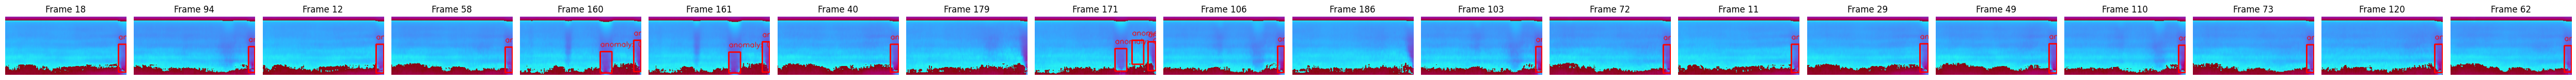

In [16]:
import scipy.io
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO

# Define the path to the new data file
new_data_filename = "/content/P2X2_train_norm.mat" # Replace with the actual path to your new data

# Load the .mat file
try:
    mat_data_new = scipy.io.loadmat(new_data_filename)
    print(f"Successfully loaded data from {new_data_filename}")

    # Assuming the data key is the same structure as the training data
    data_key = 'P2X2_train_norm' # Replace with the correct key if different
    if data_key in mat_data_new:
        data_new = mat_data_new[data_key]
        if not isinstance(data_new, np.ndarray) or data_new.ndim < 3:
             raise ValueError(f"Item under key '{data_key}' is not a numpy array with sufficient dimensions.")
        print(f"Successfully identified and loaded data from key: {data_key}")
    else:
        raise ValueError(f"Expected data key '{data_key}' not found in {new_data_filename}. Available keys: {mat_data_new.keys()}")

except FileNotFoundError:
    print(f"Error: The file {new_data_filename} was not found.")
    data_new = None # Set data_new to None to prevent further processing
except ValueError as e:
    print(f"Error loading data from {new_data_filename}: {e}")
    data_new = None


if data_new is not None:
    # --- Preprocessing (Same as training data) ---
    # Reshape the data to have frames as the first dimension
    preprocessed_data_new = np.transpose(data_new, (2, 0, 1))

    # Normalize pixel values to the range [0, 1]
    global_max_new = preprocessed_data_new.max()
    if global_max_new > 0:
        preprocessed_data_new = preprocessed_data_new / global_max_new
    else:
        print("Max pixel value of new data is 0 or less, skipping normalization by division.")


    print("Shape of preprocessed new data:", preprocessed_data_new.shape)

    # --- Load the trained YOLO model ---
    # Define the path to the trained model weights (assuming the best model from the full dataset training)
    model_path = "runs/detect/yolo_full_dataset_training/weights/best.pt"

    # Check if the model path exists
    if not os.path.exists(model_path):
        print(f"Error: Trained model not found at {model_path}. Please ensure the model was trained successfully.")
    else:
        try:
            model = YOLO(model_path)
            print(f"Successfully loaded trained model from {model_path}")

            # --- Perform Inference and Visualize ---
            print("\nPerforming inference and visualizing results...")

            # You can choose to visualize a subset of frames
            num_frames_to_visualize = 20
            frames_to_visualize = np.random.choice(preprocessed_data_new.shape[0], min(num_frames_to_visualize, preprocessed_data_new.shape[0]), replace=False)

            plt.figure(figsize=(50, len(frames_to_visualize) * 3)) # Adjusted figure size for larger output

            for i, frame_index in enumerate(frames_to_visualize):
                frame_new = preprocessed_data_new[frame_index]

                # Convert frame to the format used for training (0-255, colormapped)
                frame_uint8_new = (frame_new * 255).astype(np.uint8)
                colormapped_frame_new = cv2.applyColorMap(frame_uint8_new, cv2.COLORMAP_PLASMA)

                # Perform inference on the colormapped frame
                # YOLO expects BGR image input
                results = model(cv2.cvtColor(colormapped_frame_new, cv2.COLOR_RGB2BGR))


                # Process results and visualize
                im = colormapped_frame_new.copy() # Use the colormapped frame for visualization

                # Iterate through detections
                for r in results:
                    for box in r.boxes.data:
                        # Get class ID and confidence score
                        class_id = int(box[5])
                        confidence = float(box[4])
                        x1, y1, x2, y2 = [int(i) for i in box[:4]] # Bounding box coordinates


                        if model.names[class_id] == 'anomaly': # Check class name
                            # Draw bounding box (Red color, BGR format - but im is RGB from colormap, so use RGB red)
                            color = (255, 0, 0)  # Red color for anomaly
                            thickness = 2
                            cv2.rectangle(im, (x1, y1), (x2, y2), color, thickness)

                            # Put label (class name and confidence)
                            label = f"{model.names[class_id]}: {confidence:.2f}"
                            font = cv2.FONT_HERSHEY_SIMPLEX
                            font_scale = 0.5
                            font_thickness = 1
                            # Use RGB color for text as well
                            text_color = (255, 0, 0) # Red color for text (RGB)
                            text_size, _ = cv2.getTextSize(label, font, font_scale, font_thickness)
                            text_origin = (x1, y1 - 10) # Position the text above the box

                            # Ensure text origin is within image bounds
                            text_origin = (max(0, text_origin[0]), max(text_size[1] + 10, text_origin[1]))


                            cv2.putText(im, label, text_origin, font, font_scale, text_color, font_thickness, cv2.LINE_AA)

                plt.subplot(1, len(frames_to_visualize), i + 1)
                plt.imshow(im)
                plt.title(f'Frame {frame_index}')
                plt.axis('off')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"An error occurred during inference or visualization: {e}")

else:
    print("Skipping inference due to errors in loading or processing new data.")